# Sentiment Analysis

### Deep Learning Assignment 4

**Objective:** Develop machine learning models to classify emotions in text samples.

This notebook follows the assignment requirements: loading and preprocessing, feature extraction, Naive Bayes, Support Vector Machine (SVM), model comparison, and a final conclusion.

The assignment specifically asks for text cleaning, tokenization, stopword removal, CountVectorizer or TfidfVectorizer, Naive Bayes, SVM, and evaluation using metrics such as accuracy and F1-score.

## 1. Import Required Libraries

We first import the Python libraries needed for data handling, text preprocessing, feature extraction, model building, and evaluation.

In [1]:
import pandas as pd
import numpy as np
import re

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

import nltk
from nltk.corpus import stopwords

print('Libraries imported successfully!')

Libraries imported successfully!


## 2. Download NLTK Stopwords

Stopwords are common words such as `the`, `is`, `a`, and `and`. They usually carry little information for emotion classification, so we remove them during preprocessing.

In [2]:
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

print('Number of English stopwords:', len(stop_words))

Number of English stopwords: 198


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


## 3. Load the Dataset



In [3]:
df=pd.read_csv("/content/nlp_dataset.csv")
df.head()

,Comment,Emotion
0,i seriously hate one subject to death but now ...,fear
1,im so full of life i feel appalled,anger
2,i sit here to write i start to dig out my feel...,fear
3,ive been really angry with r and i feel like a...,joy
4,i feel suspicious if there is no one outside l...,fear


## 4. Understand the Dataset

Before preprocessing, we inspect the columns, data types, missing values, and class distribution.

In [4]:
print('Column names:')
print(df.columns.tolist())

print('\nData types:')
print(df.dtypes)

print('\nMissing values:')
print(df.isnull().sum())

Column names:
['Comment', 'Emotion']

Data types:
Comment    object
Emotion    object
dtype: object

Missing values:
Comment    0
Emotion    0
dtype: int64


In [5]:
print('Number of duplicate rows:', df.duplicated().sum())

print('\nDataset information:')
df.info()

Number of duplicate rows: 0

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5937 entries, 0 to 5936
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Comment  5937 non-null   object
 1   Emotion  5937 non-null   object
dtypes: object(2)
memory usage: 92.9+ KB


## 5. Select Text and Target Columns

Most emotion datasets contain one column containing the comment and another column containing the emotion


In [6]:

text_column = 'Comment'
target_column = 'Emotion'

X_raw = df[text_column].astype(str)
y = df[target_column]

print('Text column:', text_column)
print('Target column:', target_column)
print('\nNumber of samples:', len(df))

Text column: Comment
Target column: Emotion

Number of samples: 5937


## 6. Check the Emotion Classes

The target column contains the emotion that the model needs to predict. We check how many different classes are present.

In [7]:
print('Emotion classes:')
print(y.unique())

print('\nNumber of classes:', y.nunique())

print('\nClass distribution:')
print(y.value_counts())

Emotion classes:
['fear' 'anger' 'joy']

Number of classes: 3

Class distribution:
Emotion
anger    2000
joy      2000
fear     1937
Name: count, dtype: int64


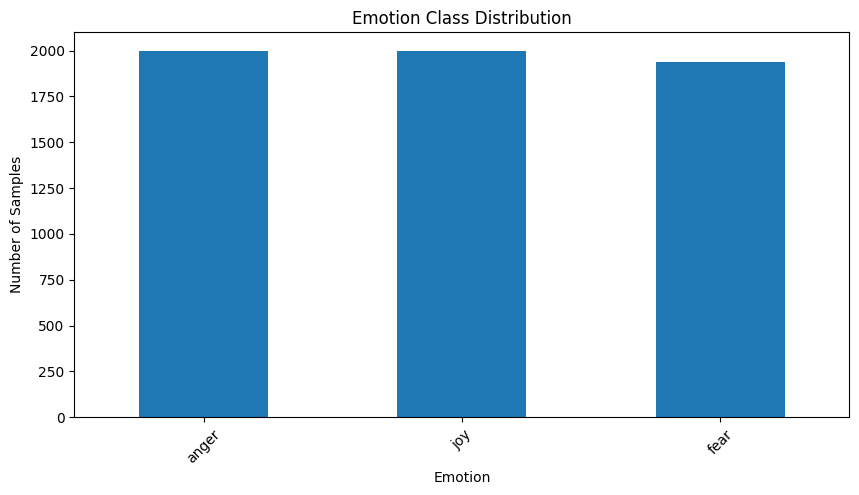

In [8]:
plt.figure(figsize=(10, 5))
y.value_counts().plot(kind='bar')
plt.title('Emotion Class Distribution')
plt.xlabel('Emotion')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45)
plt.show()

## 7. Text Preprocessing

We perform three important preprocessing operations required by the assignment:

1. **Text cleaning** – convert text to lowercase and remove unnecessary characters.
2. **Tokenization** – split a sentence into individual words.
3. **Stopword removal** – remove common English words that provide little useful information.

In [10]:
def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\\S+|www\\S+', ' ', text)

    # Keep only alphabetic characters and spaces
    text = re.sub(r'[^a-z\\s]', ' ', text)

    # Tokenization: split text into words
    tokens = text.split()

    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    # Join tokens back into a cleaned sentence
    return ' '.join(tokens)


# Apply preprocessing
df['clean_text'] = df[text_column].apply(preprocess_text)

df.head()

,Comment,Emotion,clean_text
0,i seriously hate one subject to death but now ...,fear,seriously hate one subject death feel reluctan...
1,im so full of life i feel appalled,anger,im full life feel appalled
2,i sit here to write i start to dig out my feel...,fear,sit write start dig feelings think afraid acce...
3,ive been really angry with r and i feel like a...,joy,ive really angry r feel like idiot trusting fi...
4,i feel suspicious if there is no one outside l...,fear,feel suspicious one outside like rapture happe...


### Example of preprocessing

The following cell shows how the original text changes after preprocessing.

In [11]:
for i in range(min(5, len(df))):
    print('Original :', df[text_column].iloc[i])
    print('Cleaned  :', df['clean_text'].iloc[i])
    print('-' * 80)

Original : i seriously hate one subject to death but now i feel reluctant to drop it
Cleaned  : seriously hate one subject death feel reluctant drop
--------------------------------------------------------------------------------
Original : im so full of life i feel appalled
Cleaned  : im full life feel appalled
--------------------------------------------------------------------------------
Original : i sit here to write i start to dig out my feelings and i think that i am afraid to accept the possibility that he might not make it
Cleaned  : sit write start dig feelings think afraid accept possibility might make
--------------------------------------------------------------------------------
Original : ive been really angry with r and i feel like an idiot for trusting him in the first place
Cleaned  : ive really angry r feel like idiot trusting first place
--------------------------------------------------------------------------------
Original : i feel suspicious if there is no one o

### Why preprocessing is important

- Lowercase conversion makes `Happy` and `happy` the same word.
- Removing URLs and unnecessary characters reduces noise.
- Tokenization converts sentences into individual words.
- Stopword removal reduces very common words that may not help emotion prediction.

This generally gives the feature extraction step cleaner and more useful input.

## 8. Prepare Training and Testing Data

We split the data into:

- **Training data:** used to learn patterns.
- **Testing data:** used to check how well the model works on unseen text.

Here, 80% is used for training and 20% for testing.

In [12]:
X = df['clean_text']
y = df[target_column]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print('Training samples:', len(X_train))
print('Testing samples :', len(X_test))

Training samples: 4749
Testing samples : 1188


## 9. Feature Extraction Using TF-IDF

Machine learning models cannot directly understand sentences. We need to convert text into numbers.

**TF-IDF (Term Frequency-Inverse Document Frequency)** gives a numerical importance score to words. Words that are useful for distinguishing documents receive relatively higher importance, while very common words receive lower importance.

We use `TfidfVectorizer` as the feature extraction method.

In [13]:
vectorizer = TfidfVectorizer()

# Learn vocabulary and transform training text
X_train_tfidf = vectorizer.fit_transform(X_train)

# Transform testing text using the same vocabulary
X_test_tfidf = vectorizer.transform(X_test)

print('Training TF-IDF shape:', X_train_tfidf.shape)
print('Testing TF-IDF shape :', X_test_tfidf.shape)

Training TF-IDF shape: (4749, 7735)
Testing TF-IDF shape : (1188, 7735)


### Understanding the TF-IDF output

The rows represent text samples and the columns represent words/features from the vocabulary.

For example, if the output shape is `(10000, 5000)`, it means there are 10,000 text samples and 5,000 TF-IDF word features.

In [14]:
print('Number of vocabulary words:', len(vectorizer.vocabulary_))

# Show a few vocabulary words
feature_names = vectorizer.get_feature_names_out()

print('\nFirst 20 vocabulary words:')
print(feature_names[:20])

Number of vocabulary words: 7735

First 20 vocabulary words:
['aa' 'aac' 'aaron' 'abandon' 'abandoned' 'abandonment' 'abbigail' 'abc'
 'abdomen' 'abelard' 'abide' 'abilities' 'ability' 'abit' 'able'
 'abnormally' 'abound' 'abruptly' 'absence' 'absolute']


## 10. Model 1 – Naive Bayes

Naive Bayes is a popular classification algorithm for text data. It calculates the probability of each class based on the words/features in the text.

We use `MultinomialNB`, which is commonly used with text features.

In [15]:
nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

y_pred_nb = nb_model.predict(X_test_tfidf)

print('Naive Bayes model trained successfully!')

Naive Bayes model trained successfully!


### Naive Bayes Evaluation

In [16]:
nb_accuracy = accuracy_score(y_test, y_pred_nb)

nb_f1 = f1_score(y_test, y_pred_nb, average='weighted')

print('Naive Bayes Accuracy :', round(nb_accuracy, 4))
print('Naive Bayes F1-score :', round(nb_f1, 4))
print('\nClassification Report:')
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy : 0.8897
Naive Bayes F1-score : 0.8897

Classification Report:
              precision    recall  f1-score   support

       anger       0.88      0.91      0.89       400
        fear       0.87      0.90      0.89       388
         joy       0.92      0.86      0.89       400

    accuracy                           0.89      1188
   macro avg       0.89      0.89      0.89      1188
weighted avg       0.89      0.89      0.89      1188



## 11. Model 2 – Support Vector Machine (SVM)

SVM tries to find a decision boundary that separates different classes. `LinearSVC` works well with high-dimensional sparse text features such as TF-IDF.

In [17]:
svm_model = LinearSVC(random_state=42)

svm_model.fit(X_train_tfidf, y_train)

y_pred_svm = svm_model.predict(X_test_tfidf)

print('SVM model trained successfully!')

SVM model trained successfully!


### SVM Evaluation

In [18]:
svm_accuracy = accuracy_score(y_test, y_pred_svm)

svm_f1 = f1_score(y_test, y_pred_svm, average='weighted')

print('SVM Accuracy :', round(svm_accuracy, 4))
print('SVM F1-score :', round(svm_f1, 4))

print('\nClassification Report:')
print(classification_report(y_test, y_pred_svm))

SVM Accuracy : 0.9411
SVM F1-score : 0.941

Classification Report:
              precision    recall  f1-score   support

       anger       0.95      0.93      0.94       400
        fear       0.94      0.93      0.94       388
         joy       0.93      0.96      0.95       400

    accuracy                           0.94      1188
   macro avg       0.94      0.94      0.94      1188
weighted avg       0.94      0.94      0.94      1188



## 12. Confusion Matrix – Naive Bayes

A confusion matrix shows how many samples were correctly and incorrectly classified for each emotion.

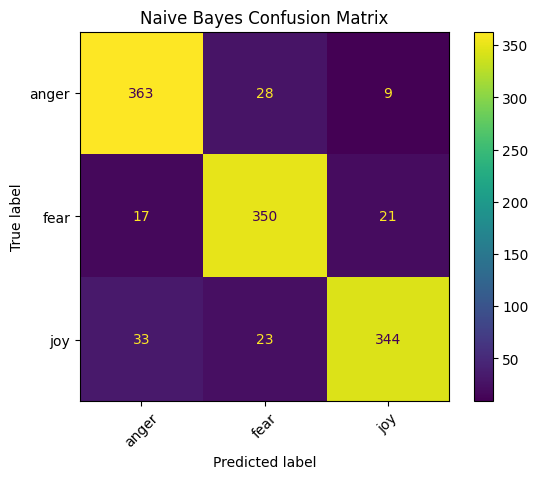

In [19]:
cm_nb = confusion_matrix(y_test, y_pred_nb, labels=nb_model.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=nb_model.classes_)
disp.plot(xticks_rotation=45)
plt.title('Naive Bayes Confusion Matrix')
plt.show()

## 13. Confusion Matrix – SVM

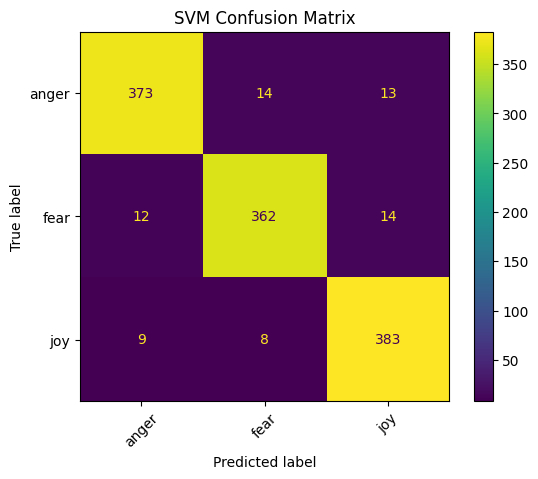

In [20]:
cm_svm = confusion_matrix(y_test, y_pred_svm, labels=svm_model.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=svm_model.classes_)
disp.plot(xticks_rotation=45)
plt.title('SVM Confusion Matrix')
plt.show()

## 14. Compare Both Models

We now place the accuracy and F1-score of both models into one DataFrame so that they can be compared easily.

In [21]:
results = pd.DataFrame({
    'Model': ['Naive Bayes', 'Support Vector Machine'],
    'Accuracy': [nb_accuracy, svm_accuracy],
    'F1 Score': [nb_f1, svm_f1]
})

results = results.sort_values('F1 Score', ascending=False).reset_index(drop=True)

results

,Model,Accuracy,F1 Score
0,Support Vector Machine,0.941077,0.941049
1,Naive Bayes,0.889731,0.889717


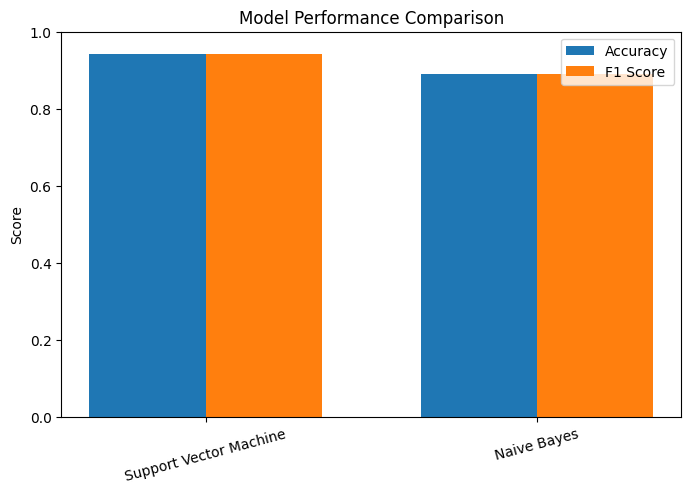

In [22]:
plt.figure(figsize=(8, 5))

x = np.arange(len(results))
width = 0.35

plt.bar(x - width/2, results['Accuracy'], width, label='Accuracy')
plt.bar(x + width/2, results['F1 Score'], width, label='F1 Score')

plt.xticks(x, results['Model'], rotation=15)
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.legend()
plt.show()

## 15. Select the Best Model

For emotion classification, F1-score is useful because it considers both precision and recall. We select the model with the highest weighted F1-score.

In [23]:
best_model_name = results.loc[0, 'Model']
best_f1 = results.loc[0, 'F1 Score']
best_accuracy = results.loc[0, 'Accuracy']

print('Best Model:', best_model_name)
print('Accuracy:', round(best_accuracy, 4))
print('F1 Score:', round(best_f1, 4))

Best Model: Support Vector Machine
Accuracy: 0.9411
F1 Score: 0.941


## 18. Test the Model with New Text

We can use the trained models to predict the emotion of a new sentence. The new sentence must go through the **same preprocessing and TF-IDF transformation** used during training.

In [24]:
def predict_emotion(text, model):
    cleaned_text = preprocess_text(text)
    text_vector = vectorizer.transform([cleaned_text])
    prediction = model.predict(text_vector)[0]
    return prediction


sample_texts = [
    'I am extremely happy today',
    'I feel very sad and disappointed',
    'I am angry about what happened'
]

for text in sample_texts:
    print('Text:', text)
    print('Naive Bayes prediction:', predict_emotion(text, nb_model))
    print('SVM prediction        :', predict_emotion(text, svm_model))
    print('-' * 70)

Text: I am extremely happy today
Naive Bayes prediction: joy
SVM prediction        : joy
----------------------------------------------------------------------
Text: I feel very sad and disappointed
Naive Bayes prediction: anger
SVM prediction        : joy
----------------------------------------------------------------------
Text: I am angry about what happened
Naive Bayes prediction: anger
SVM prediction        : anger
----------------------------------------------------------------------


## 19. Final Conclusion

In this project, text data was cleaned, tokenized, and processed by removing English stopwords. TF-IDF was used to convert the text into numerical features. Two machine learning classification models, Naive Bayes and Support Vector Machine, were trained and evaluated using accuracy and weighted F1-score.

The model comparison table identifies the better-performing model based on F1-score. The selected model is more suitable for this dataset because it achieved the higher evaluation score on unseen test data.

